In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import data_prep

In [87]:
data = pd.read_csv('../data/Students_Performance_dataset.csv')

In [88]:
data.head()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [89]:
data.columns

Index(['University Admission year', 'Gender', 'Age', 'H.S.C passing year',
       'Program', 'Current Semester', 'Do you have meritorious scholarship ?',
       'Do you use University transportation?',
       'How many hour do you study daily?',
       'How many times do you seat for study in a day?',
       'What is your preferable learning mode?', 'Do you use smart phone?',
       'Do you have personal Computer?',
       'How many hour do you spent daily in social media?',
       'Status of your English language proficiency',
       'Average attendance on class', 'Did you ever fall in probation?',
       'Did you ever got suspension?',
       'Do you attend in teacher consultancy for any kind of academical problems?',
       'What are the skills do you have ?',
       'How many hour do you spent daily on your skill development?',
       'What is you interested area?', 'What is your relationship status?',
       'Are you engaged with any co-curriculum activities?',
       'With whom y

In [90]:
# checking for missing vals
data.isnull().sum().sum()

np.int64(1)

In [91]:
# finding the one missing value
missing_value = data.isnull().sum()
missing_value[missing_value > 0]

What are the skills do you have ?    1
dtype: int64

In [92]:
# Apply data prep function
data = data_prep.data_prep(data)

In [93]:
data.head()

,university_admission_year,gender,age,hs_grad_year,program,semester,scholarship,transportation,study_hours,study_seatings,...,interest_area,relationship_status,co_curriculars,living_situation,health_issues,semester_gpa,disabilities,cumulative_gpa,credits,family_income
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [94]:
data.columns

Index(['university_admission_year', 'gender', 'age', 'hs_grad_year', 'program',
       'semester', 'scholarship', 'transportation', 'study_hours',
       'study_seatings', 'learning_mode', 'smartphone', 'computer',
       'social_media_hours', 'english_proficiency', 'attendance', 'probation',
       'suspension', 'teacher_consultation', 'skills', 'skill_hours',
       'interest_area', 'relationship_status', 'co_curriculars',
       'living_situation', 'health_issues', 'semester_gpa', 'disabilities',
       'cumulative_gpa', 'credits', 'family_income'],
      dtype='object')

In [95]:
# finding numeric cols
numeric_cols = data.select_dtypes(include='number').columns
numeric_cols

Index(['university_admission_year', 'age', 'hs_grad_year', 'semester',
       'study_hours', 'study_seatings', 'social_media_hours', 'skill_hours',
       'semester_gpa', 'cumulative_gpa', 'credits', 'family_income'],
      dtype='object')

In [96]:
# object type variables
categorical_cols = data.select_dtypes(include='object').columns
categorical_cols

Index(['gender', 'program', 'scholarship', 'transportation', 'learning_mode',
       'smartphone', 'computer', 'english_proficiency', 'attendance',
       'probation', 'suspension', 'teacher_consultation', 'skills',
       'interest_area', 'relationship_status', 'co_curriculars',
       'living_situation', 'health_issues', 'disabilities'],
      dtype='object')

In [97]:
data.describe()

,university_admission_year,age,hs_grad_year,semester,study_hours,study_seatings,social_media_hours,skill_hours,semester_gpa,cumulative_gpa,credits,family_income
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1.194000e+03
mean,2020.515075,21.343384,2019.214405,6.539363,3.131491,1.940536,3.289782,2.185092,2.683945,3.165603,71.842546,6.248812e+04
std,1.354954,1.613338,1.380960,3.809884,1.649597,0.856305,2.289547,1.296101,0.871592,0.750132,48.074338,7.617356e+04
min,2013.000000,18.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,2020.000000,20.000000,2019.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.200000,2.900000,23.000000,3.000000e+04
50%,2021.000000,21.000000,2020.000000,7.000000,3.000000,2.000000,3.000000,2.000000,2.680000,3.210000,78.000000,5.000000e+04
75%,2022.000000,22.000000,2020.000000,10.000000,4.000000,2.000000,4.000000,3.000000,3.380000,3.670000,117.000000,7.400000e+04
max,2023.000000,27.000000,2028.000000,24.000000,13.000000,7.000000,20.000000,12.000000,4.000000,4.000000,145.000000,2.000000e+06


In [98]:
# Print data attributes
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

Number of rows: 1194
Number of columns: 31


In [99]:
# Count duplicates
duplicates = data.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


In [100]:
# Print NA Entries
nas = data.isna().sum().sum()
print(f"Number of NA entries: {nas}")

Number of NA entries: 0


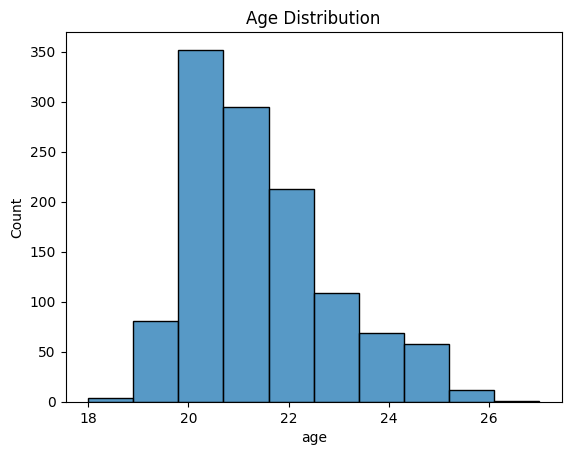

age
20    352
21    295
22    213
23    109
19     81
24     69
25     58
26     12
18      4
27      1
Name: count, dtype: int64


In [101]:
# Visualize age distribution

sns.histplot(data['age'], bins=10)
plt.title('Age Distribution')
plt.show()

print(data['age'].value_counts())

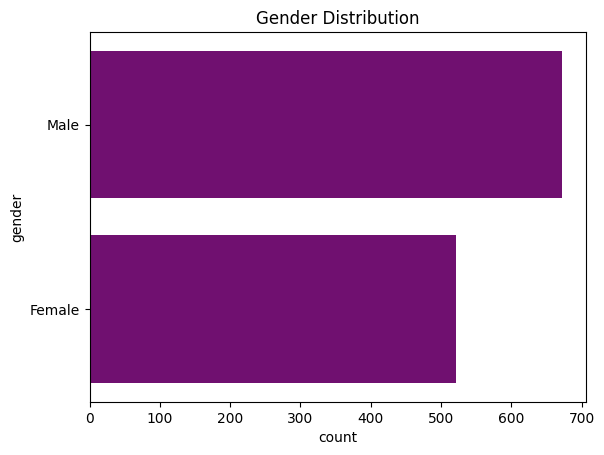

In [102]:
# Visualize gender distribution

sns.countplot(data['gender'], color='purple')
plt.title('Gender Distribution')
plt.show()

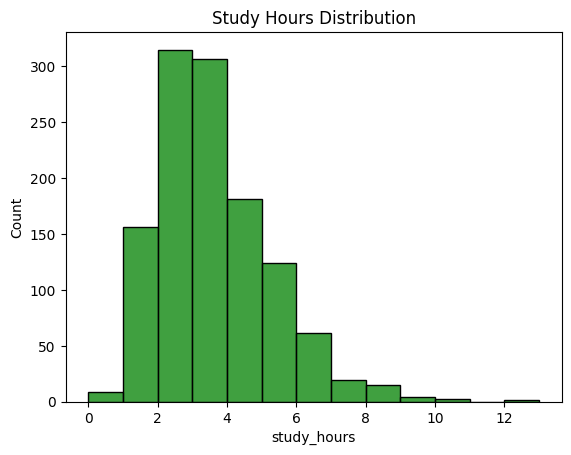

In [103]:
# Visualize study_hours distribution

sns.histplot(data['study_hours'], bins=13, color="green")
plt.title('Study Hours Distribution')
plt.show()


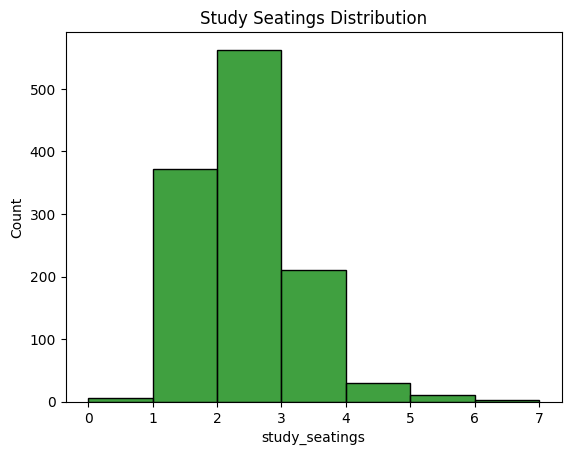

In [104]:
# Visualize study_seatings distribution

sns.histplot(data['study_seatings'], bins=7, color="green")
plt.title('Study Seatings Distribution')
plt.show()

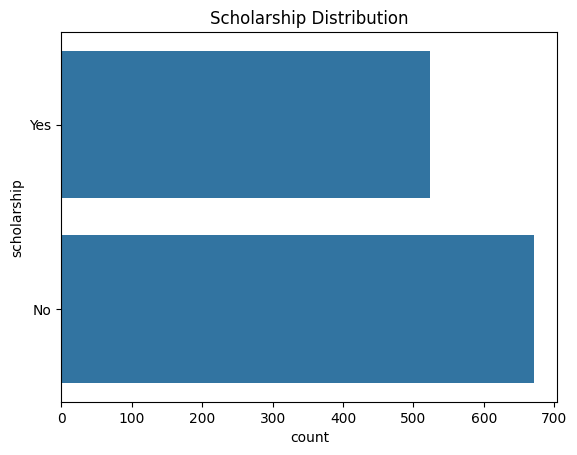

In [105]:
# Visualize scholarship distribution

sns.countplot(data['scholarship'])
plt.title('Scholarship Distribution')
plt.show()


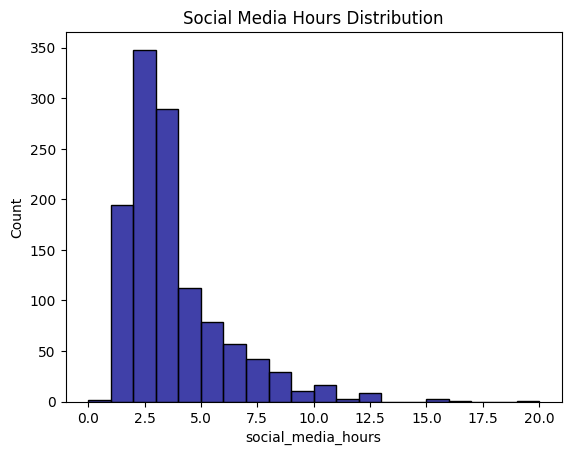

In [115]:
# Visualize social_media_hours distribution

sns.histplot(data['social_media_hours'], bins=20, color="darkblue")
plt.title('Social Media Hours Distribution')
plt.show()

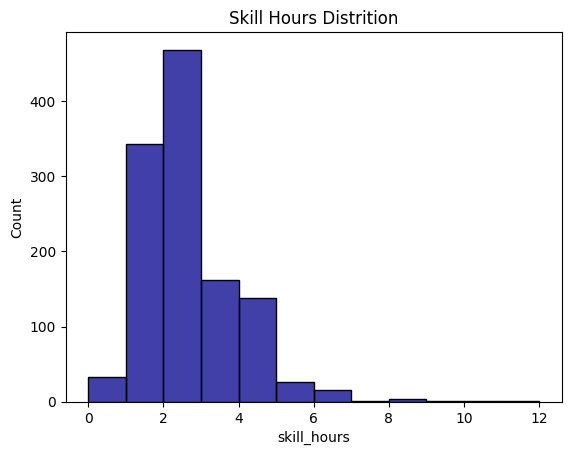

In [107]:
# Visualize skill_hours distribution

sns.histplot(data['skill_hours'], bins=12, color="darkblue")
plt.title("Skill Hours Distrition")
plt.show()

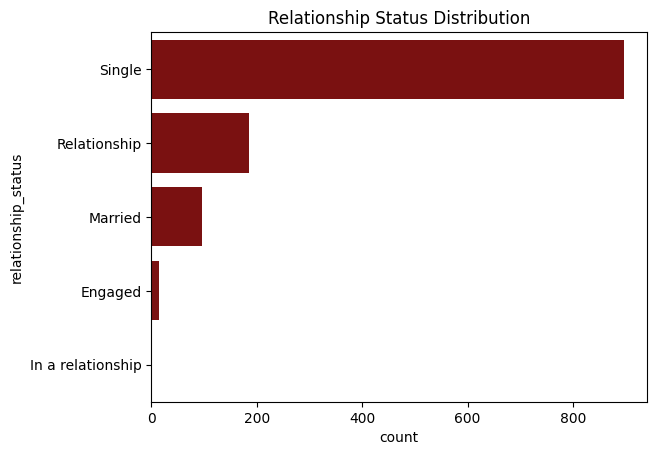

In [108]:
# Visualize relationship status counts

sns.countplot(data["relationship_status"], color="darkred")
plt.title("Relationship Status Distribution")
plt.show()

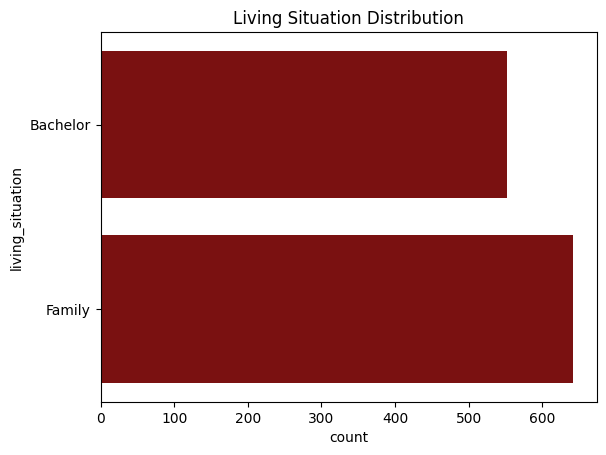

In [109]:
# Visualize living situation counts

sns.countplot(data["living_situation"], color="darkred")
plt.title("Living Situation Distribution")
plt.show()

Unique skills: 56


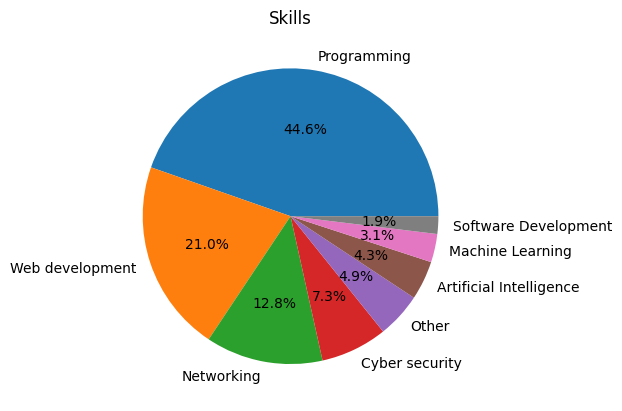

In [110]:
# Visualize most common skills

print("Unique skills:", data['skills'].nunique())

# Convert low-reported skills to "Other"
counts = data["skills"].value_counts()
other_skills = counts[counts < 20].index
skills_updated = data['skills'].replace(other_skills, "Other")

skills_updated_counts = skills_updated.value_counts()
skills_updated_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Skills")
plt.ylabel("")
plt.show()

Unique interestareas: 25


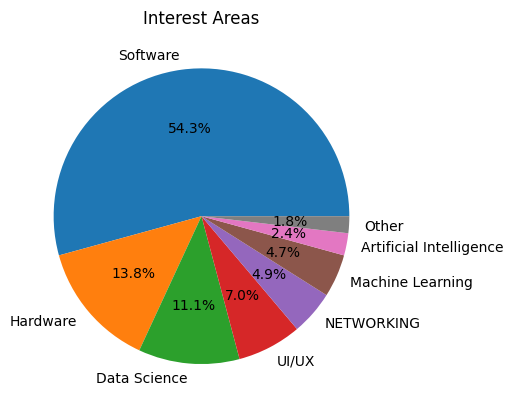

In [111]:
# Visualize interest areas

print("Unique interestareas:", data['interest_area'].nunique())

# Convert low-reported areas to "Other"
interest_counts = data['interest_area'].value_counts()
other_interests = interest_counts[interest_counts < 20].index
interest_updated = data['interest_area'].replace(other_interests, "Other")

interest_updated_counts = interest_updated.value_counts()
interest_updated_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Interest Areas")
plt.ylabel("")
plt.show()

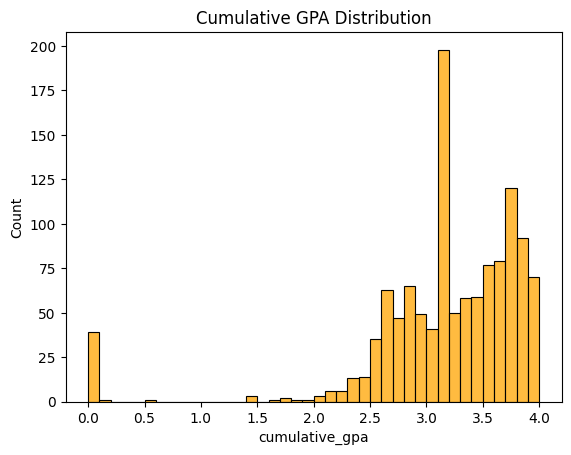

In [112]:
# Visualize cumulative_gpa distribution

sns.histplot(data['cumulative_gpa'], bins=40, color="orange")
plt.title('Cumulative GPA Distribution')
plt.show()
